# Modelo Variação 1: DenseNet-121 (Sem Early Stop)

Esta variação mantém as configurações do Baseline, mas com duas mudanças específicas:
- **Sem Early Stopping:** O modelo treinará obrigatoriamente por todas as épocas.
- **Épocas Fixas:** Definido para 50 épocas.
- **Arquitetura:** DenseNet-121 (Backbone 100% congelado).
- **Data Augmentation:** Leve (Resize + Horizontal Flip).

In [1]:
# =========================================================
# Setup: Bibliotecas e Reprodutibilidade
# =========================================================
import os, random, warnings, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, f1_score, classification_report

import torch, torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()
print(f"Device: {device} | AMP: {use_amp}")

# Diretório para salvar os modelos
SAVE_DIR = Path("../models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda | AMP: True


In [2]:
# ============================
# Configuração do Dataset
# ============================
DATA_ROOT = Path('/home/gustavom/Documents/Orange/Brain Tumor MRI Dataset')
TRAIN_DIR = DATA_ROOT / "Training"
TEST_DIR  = DATA_ROOT / "Testing"

assert TRAIN_DIR.exists(), f"Pasta {TRAIN_DIR} não encontrada."
assert TEST_DIR.exists(), f"Pasta {TEST_DIR} não encontrada."

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Augmentation LEVE
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = datasets.ImageFolder(TEST_DIR,  transform=val_tfms)

class_names = train_ds.classes
print("Classes encontradas:", class_names)
print(f"Qtd Treino: {len(train_ds)} | Qtd Teste/Val: {len(val_ds)}")

batch_size = 32
num_workers = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

Classes encontradas: ['glioma', 'meningioma', 'notumor', 'pituitary']
Qtd Treino: 5600 | Qtd Teste/Val: 1600


In [3]:
# ============================
# Modelo: DenseNet-121 Variação 1
# ============================
weights = models.DenseNet121_Weights.IMAGENET1K_V1
model = models.densenet121(weights=weights)

# Congela TODO o backbone
for p in model.features.parameters():
    p.requires_grad = False

# Cabeça treinável
num_classes = len(class_names)
in_feats = model.classifier.in_features
model.classifier = nn.Linear(in_feats, num_classes)

model = model.to(device)

In [4]:
# ============================
# Otimização
# ============================
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

In [5]:
# ============================
# Funções de Treino e Plot
# ============================
def run_epoch(model, loader, train=True):
    model.train(mode=train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    for X, y in loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(X)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                logits = model(X)
                loss = criterion(logits, y)

        preds = logits.argmax(1)
        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    avg_loss = total_loss / total
    acc = total_correct / total
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    f1 = f1_score(y_true, y_pred, average='macro')
    return avg_loss, acc, f1, y_true, y_pred

def plot_curve(hist, k1, k2, title, ylab):
    plt.figure(figsize=(6,4))
    plt.plot(hist[k1], label=k1)
    plt.plot(hist[k2], label=k2)
    plt.xlabel("epoch"); plt.ylabel(ylab); plt.title(title); plt.legend(); plt.show()

def plot_cm(cm, classes, normalize=False, title="Confusion Matrix"):
    if normalize: cm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
    import itertools
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues); plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes)); plt.xticks(ticks, classes, rotation=45); plt.yticks(ticks, classes)
    fmt = ".2f" if normalize else "d"; thresh = cm.max()/2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha="center",
                 color="white" if cm[i,j] > thresh else "black")
    plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.show()

In [6]:
# ============================
# Treinamento
# ============================
EPOCHS = 50
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_f1":[]}
SAVE_PATH = SAVE_DIR / "variation1_densenet121.pth"

print(f"Iniciando treinamento (Variação 1 - {EPOCHS} épocas)...")
for e in range(1, EPOCHS+1):
    tr_loss, tr_acc, _, _, _ = run_epoch(model, train_loader, train=True)
    va_loss, va_acc, va_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)

    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc); history["val_f1"].append(va_f1)

    print(f"[{e}/{EPOCHS}] train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")

# Salva o modelo final
torch.save({k: v.detach().cpu() for k, v in model.state_dict().items()}, SAVE_PATH)
print(f"Modelo final salvo em {SAVE_PATH}")

Iniciando treinamento (Variação 1 - 50 épocas)...
[1/50] train_loss=0.6412 acc=0.7891 | val_loss=0.5555 acc=0.8006 f1=0.7923
[2/50] train_loss=0.3799 acc=0.8707 | val_loss=0.4921 acc=0.8306 f1=0.8253
[3/50] train_loss=0.3186 acc=0.8909 | val_loss=0.4712 acc=0.8419 f1=0.8374
[4/50] train_loss=0.3049 acc=0.8934 | val_loss=0.4965 acc=0.8313 f1=0.8254
[5/50] train_loss=0.2805 acc=0.9016 | val_loss=0.4513 acc=0.8538 f1=0.8527
[6/50] train_loss=0.2686 acc=0.9034 | val_loss=0.4400 acc=0.8588 f1=0.8585
[7/50] train_loss=0.2491 acc=0.9132 | val_loss=0.4683 acc=0.8525 f1=0.8482
[8/50] train_loss=0.2455 acc=0.9123 | val_loss=0.4504 acc=0.8575 f1=0.8544
[9/50] train_loss=0.2312 acc=0.9198 | val_loss=0.4342 acc=0.8644 f1=0.8612
[10/50] train_loss=0.2417 acc=0.9082 | val_loss=0.4505 acc=0.8638 f1=0.8605
[11/50] train_loss=0.2242 acc=0.9198 | val_loss=0.3940 acc=0.8775 f1=0.8751
[12/50] train_loss=0.2155 acc=0.9252 | val_loss=0.4688 acc=0.8700 f1=0.8673
[13/50] train_loss=0.2183 acc=0.9196 | val_loss

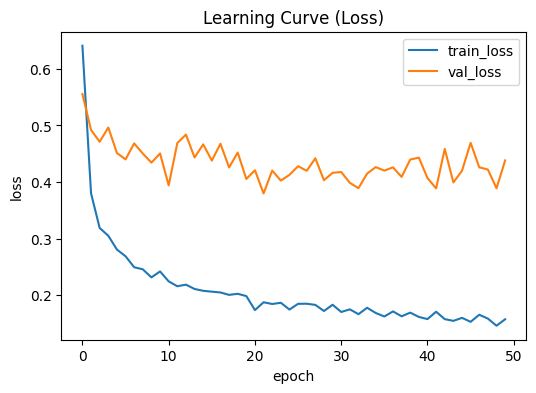

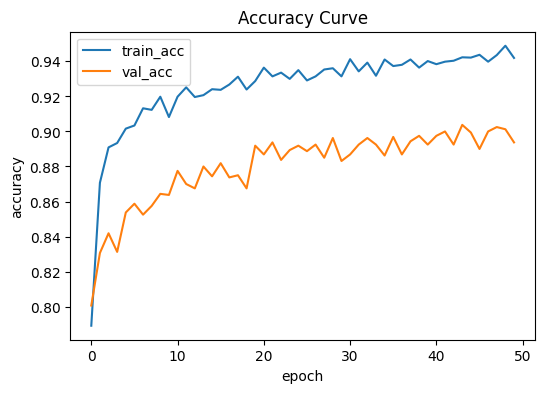

Modelo carregado de ../models/variation1_densenet121.pth

F1-Score Final (Macro): 0.8913

Classification Report:
               precision    recall  f1-score   support

      glioma       0.96      0.73      0.83       400
  meningioma       0.82      0.87      0.85       400
     notumor       0.90      0.99      0.95       400
   pituitary       0.91      0.97      0.94       400

    accuracy                           0.89      1600
   macro avg       0.90      0.89      0.89      1600
weighted avg       0.90      0.89      0.89      1600



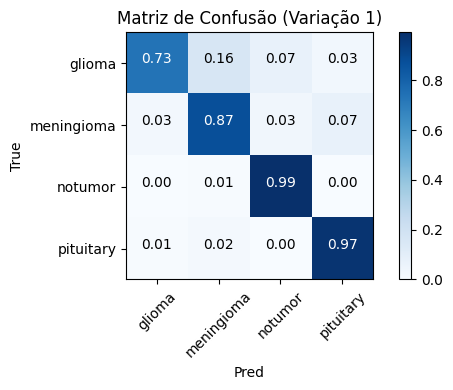

In [7]:
# ============================
# Resultados Finais
# ============================
plot_curve(history, "train_loss", "val_loss", "Learning Curve (Loss)", "loss")
plot_curve(history, "train_acc",  "val_acc",  "Accuracy Curve", "accuracy")

# Carrega o modelo final e avalia
if os.path.exists(SAVE_PATH):
    state = torch.load(SAVE_PATH, map_location=device)
    model.load_state_dict(state)
    print(f"Modelo carregado de {SAVE_PATH}")

_, _, val_f1, y_true, y_pred = run_epoch(model, val_loader, train=False)

print(f"\nF1-Score Final (Macro): {val_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plot_cm(cm, class_names, normalize=True, title="Matriz de Confusão (Variação 1)")